<a href="https://colab.research.google.com/github/spokenprim618/cmp-415/blob/main/Copy_of_Following_of_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

For this second step of the project I have chosen ["Time Series Air Quality Data of India (2010-2023)"](https://www.kaggle.com/datasets/abhisheksjha/time-series-air-quality-data-of-india-2010-2023?resource=download&select=BR003.csv). The goal of the usage of this new dataset is to make models that can accurately predict air quality.

###**Imports**

In [ ]:
import os
import datetime
import glob
import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import kagglehub
mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

Import path and set for each stations info:

In [ ]:
path = kagglehub.dataset_download(
    "abhisheksjha/time-series-air-quality-data-of-india-2010-2023"
)

print(path)

df_states = pd.read_csv(f'{path}/stations_info.csv')
df_states.drop(columns=['agency', 'station_location', 'start_month'], inplace=True)
unique_states = df_states['state'].unique()

/root/.cache/kagglehub/datasets/abhisheksjha/time-series-air-quality-data-of-india-2010-2023/versions/2


Show top 5

In [ ]:
df_states.head()

,file_name,state,city,start_month_num,start_year
0,AP001,Andhra Pradesh,Tirupati,7,2016
1,AP002,Andhra Pradesh,Vijayawada,5,2017
2,AP003,Andhra Pradesh,Visakhapatnam,7,2017
3,AP004,Andhra Pradesh,Rajamahendravaram,9,2017
4,AP005,Andhra Pradesh,Amaravati,11,2017


Due to so many sectioned csv's this function combines all of them into a single dataframe. There is choosing specific columns to be used due to many columns not being needed for the analysis and ram limits

In [ ]:
COLUMNS_TO_KEEP = [
    "From Date",
    "PM2.5 (ug/m3)",
    "PM10 (ug/m3)",
    "NO2 (ug/m3)",
    "SO2 (ug/m3)",
    "CO (mg/m3)",
    "Ozone (ug/m3)",
    "Temp (degree C)",
    "RH (%)",
    "WS (m/s)",
    "RF (mm)"
]


def combine_all_station_data():

    # store all station dataframes here
    all_dataframes = []

    # get all csv files
    csv_files = glob.glob(f"{path}/*.csv")

    print(f"Found {len(csv_files)} csv files\n")

    for file_path in csv_files:

        # get filename only
        file_name = os.path.basename(file_path).replace(".csv", "")

        # skip metadata file
        if file_name == "stations_info":
            continue

        try:

            # read ONLY the header first
            temp_df = pd.read_csv(file_path, nrows=0)

            # keep only columns that exist in THIS file
            valid_columns = [
                col for col in COLUMNS_TO_KEEP
                if col in temp_df.columns
            ]

            # load only valid columns
            df = pd.read_csv(
                file_path,
                usecols=valid_columns
            )

            # reduce memory usage
            float_cols = df.select_dtypes(include='float64').columns
            df[float_cols] = df[float_cols].astype('float32')

            # find matching station info
            station_row = df_states[
                df_states["file_name"] == file_name
            ]

            # skip if metadata missing
            if station_row.empty:
                print(f"Skipping {file_name} (no metadata)")
                continue

            # add state + city columns
            df["state"] = station_row["state"].values[0]
            df["city"] = station_row["city"].values[0]

            # optional: add source station id
            df["station_id"] = file_name

            # add dataframe to list
            all_dataframes.append(df)

            print(
                f"Added {file_name} | "
                f"Columns: {len(valid_columns)} | "
                f"Shape: {df.shape}"
            )

        except Exception as e:
            print(f"Error reading {file_name}: {e}")

    # combine all dataframes
    combined_df = pd.concat(
        all_dataframes,
        ignore_index=True
    )

    return combined_df

In [ ]:
combined_df = combine_all_station_data()
combined_df.head()

Found 454 csv files

Added KA016 | Columns: 11 | Shape: (32439, 14)
Added HR016 | Columns: 10 | Shape: (37075, 13)
Added HR026 | Columns: 10 | Shape: (26937, 13)
Added RJ024 | Columns: 10 | Shape: (751, 13)
Added CG014 | Columns: 10 | Shape: (1855, 13)
Added DL023 | Columns: 10 | Shape: (45230, 13)
Added MH030 | Columns: 6 | Shape: (20842, 9)
Added MP001 | Columns: 11 | Shape: (53502, 14)
Added TN026 | Columns: 10 | Shape: (367, 13)
Added KL005 | Columns: 6 | Shape: (27948, 9)
Added KA015 | Columns: 11 | Shape: (32438, 14)
Added KL009 | Columns: 10 | Shape: (21605, 13)
Added KA007 | Columns: 11 | Shape: (41771, 14)
Added DL010 | Columns: 9 | Shape: (110648, 12)
Added UP054 | Columns: 10 | Shape: (7257, 13)
Added DL007 | Columns: 9 | Shape: (113962, 12)
Added UP037 | Columns: 10 | Shape: (14942, 13)
Added GJ012 | Columns: 10 | Shape: (15681, 13)
Added MH001 | Columns: 11 | Shape: (116089, 14)
Added MH019 | Columns: 10 | Shape: (33466, 13)
Added HR010 | Columns: 9 | Shape: (37210, 12)
Ad

,From Date,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),SO2 (ug/m3),CO (mg/m3),Ozone (ug/m3),Temp (degree C),RH (%),WS (m/s),RF (mm),state,city,station_id
0,2019-07-19 09:00:00,0.64,26.360001,12.34,NaN,0.3,45.080002,NaN,70.720001,3.30,NaN,Karnataka,Chamarajanagar,KA016
1,2019-07-19 10:00:00,0.57,24.639999,11.43,2.70,0.3,44.919998,NaN,68.430000,3.02,0.0,Karnataka,Chamarajanagar,KA016
2,2019-07-19 11:00:00,4.85,21.840000,13.73,3.90,0.3,45.270000,NaN,69.029999,2.68,0.0,Karnataka,Chamarajanagar,KA016
3,2019-07-19 12:00:00,10.75,20.620001,10.53,2.52,0.3,45.369999,NaN,68.589996,3.61,0.0,Karnataka,Chamarajanagar,KA016
4,2019-07-19 13:00:00,8.44,18.629999,10.55,3.50,0.3,44.930000,NaN,62.779999,4.06,0.0,Karnataka,Chamarajanagar,KA016


count and percent of nans on each column

In [ ]:
nan_counts = combined_df.isna().sum()

print(nan_counts)

nan_summary = pd.DataFrame({
    "NaN Count": combined_df.isna().sum(),
    "NaN Percent": (
        combined_df.isna().mean() * 100
    ).round(2)
})

print(nan_summary)

From Date                 0
PM2.5 (ug/m3)       3937969
PM10 (ug/m3)        4869779
NO2 (ug/m3)         3111384
SO2 (ug/m3)         3698661
CO (mg/m3)          3671011
Ozone (ug/m3)       3919575
Temp (degree C)    10337686
RH (%)              4967276
WS (m/s)            4615081
RF (mm)             8339606
state                     0
city                      0
station_id                0
dtype: int64
                 NaN Count  NaN Percent
From Date                0         0.00
PM2.5 (ug/m3)      3937969        27.55
PM10 (ug/m3)       4869779        34.06
NO2 (ug/m3)        3111384        21.76
SO2 (ug/m3)        3698661        25.87
CO (mg/m3)         3671011        25.68
Ozone (ug/m3)      3919575        27.42
Temp (degree C)   10337686        72.31
RH (%)             4967276        34.75
WS (m/s)           4615081        32.28
RF (mm)            8339606        58.34
state                    0         0.00
city                     0         0.00
station_id               0         

Due to temperature Temp (degree C)  and rain fall RF (mm) large percentage of NAN, they will be removed. It is acknowledged that these features may not have been needed, possible, or collected in certain regions. Data such as rainfall or no rain fall could be good for added prediction power because every region differs in this aspect. But for simplicity will be removed.

In [ ]:
combined_df = combined_df.drop(
    columns=[
        "Temp (degree C)",
        "RF (mm)"
    ]
)

Show the change of T, p, and rho over time

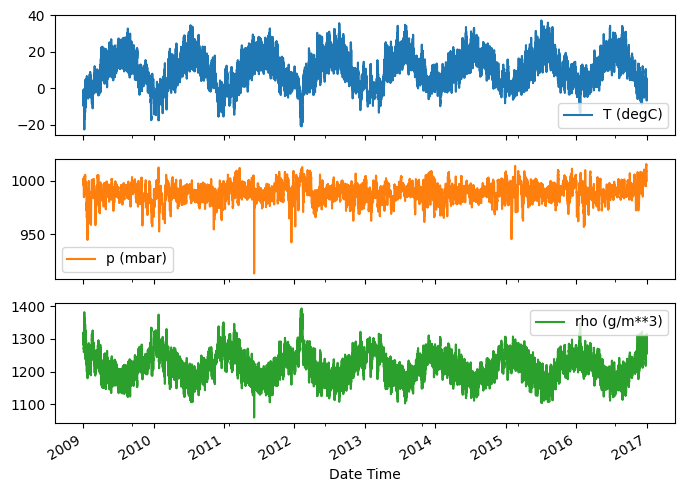

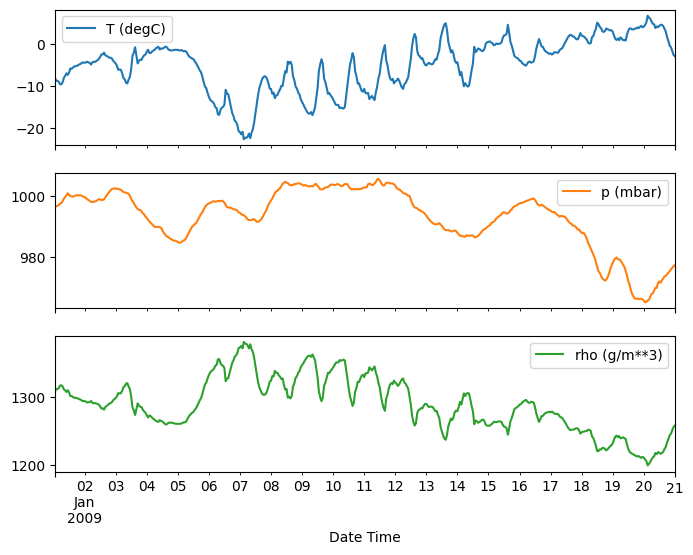

In [ ]:
plot_cols = ['T (degC)', 'p (mbar)', 'rho (g/m**3)']
plot_features = df[plot_cols]
plot_features.index = date_time
_ = plot_features.plot(subplots=True)

plot_features = df[plot_cols][:480]
plot_features.index = date_time[:480]
_ = plot_features.plot(subplots=True)

####**Inpsection and clean up**

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


In [ ]:
# remove -999 and 0 from wind speed

wv = df['wv (m/s)']
bad_wv = wv == -9999.0
wv[bad_wv] = 0.0

max_wv = df['max. wv (m/s)']
bad_max_wv = max_wv == -9999.0
max_wv[bad_max_wv] = 0.0

# The above inplace edits are reflected in the DataFrame.
df['wv (m/s)'].min()

0.0

Text(0, 0.5, 'Wind Velocity [m/s]')

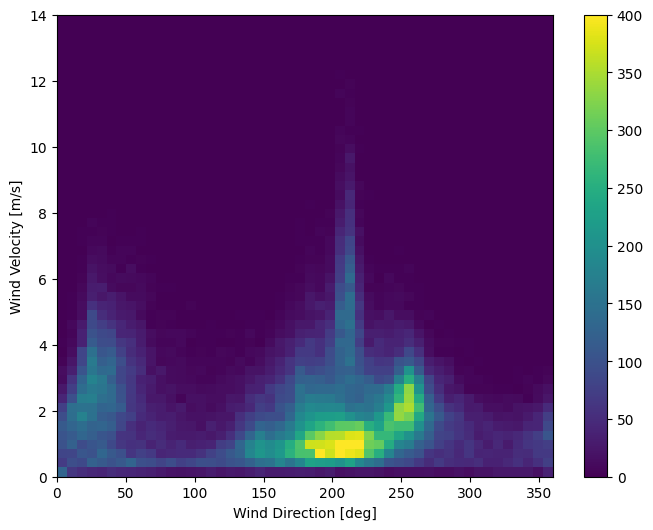

In [ ]:
# Check the dist of wind

plt.hist2d(df['wd (deg)'], df['wv (m/s)'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

Direction through degrees a circular measurment is not good due to models them assuming a linear structure
So they can be converted through sin and cosine to have linear meaning and distance.
Then put them into vectors.


In [ ]:
wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

# Convert to radians.
wd_rad = df.pop('wd (deg)')*np.pi / 180

# Calculate the wind x and y components.
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

# Calculate the max wind x and y components.
df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

(np.float64(-11.305513973134667),
 np.float64(8.24469928549079),
 np.float64(-8.27438540335515),
 np.float64(7.7338312955467785))

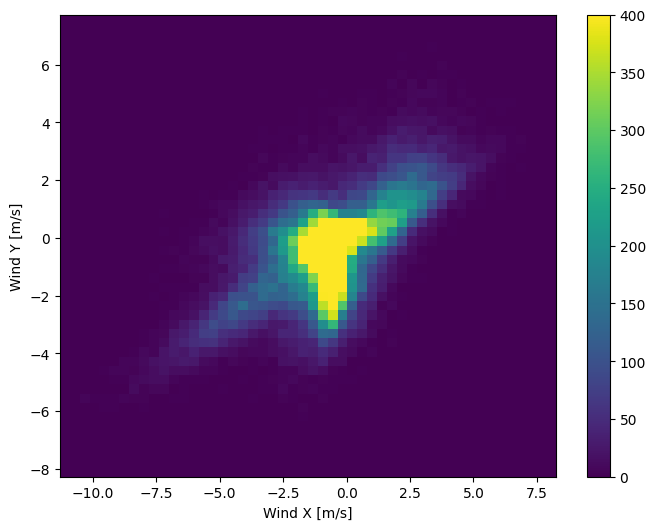

In [ ]:
plt.hist2d(df['Wx'], df['Wy'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

Change to date time and change the circular nature of dates as well

Text(0.5, 1.0, 'Time of day signal')

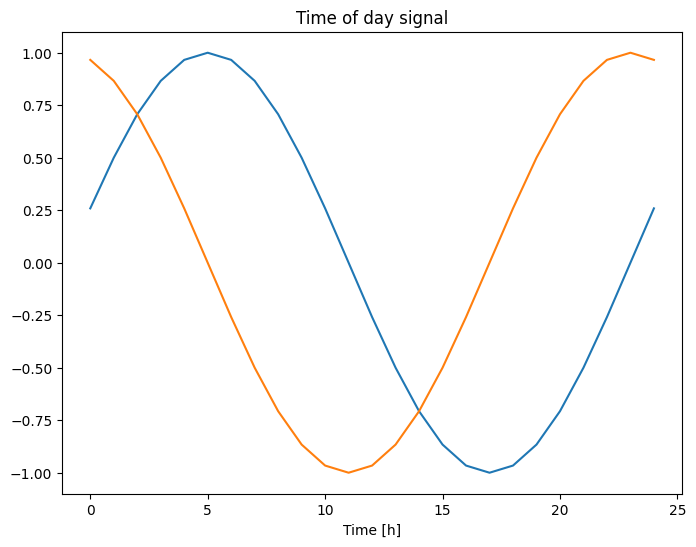

In [ ]:
timestamp_s = date_time.map(pd.Timestamp.timestamp)
day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

You can find the most important features and patterns through the fast fourier transform. The log scale compresses the data as a form of normilization.

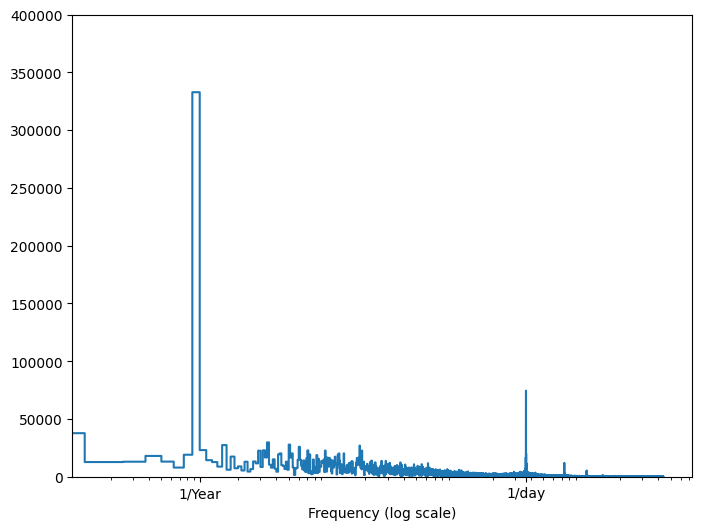

In [ ]:
fft = tf.signal.rfft(df['T (degC)'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df['T (degC)'])
hours_per_year = 24*365.2524
years_per_dataset = n_samples_h/(hours_per_year)

f_per_year = f_per_dataset/years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 400000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524], labels=['1/Year', '1/day'])
_ = plt.xlabel('Frequency (log scale)')

Split the data but no shuffling to maintain some order as this is time series data these patterns hold information

In [ ]:
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

data normilization through simple averages interesting to think about how only training data is used for this and how moving averages could be more honest

In [ ]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

view distribution through violin plots. The medians are all in similiar ranges but there are many with long tails but some with no tails through each feature

/tmp/ipykernel_1972/3214313372.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(df.keys(), rotation=90)


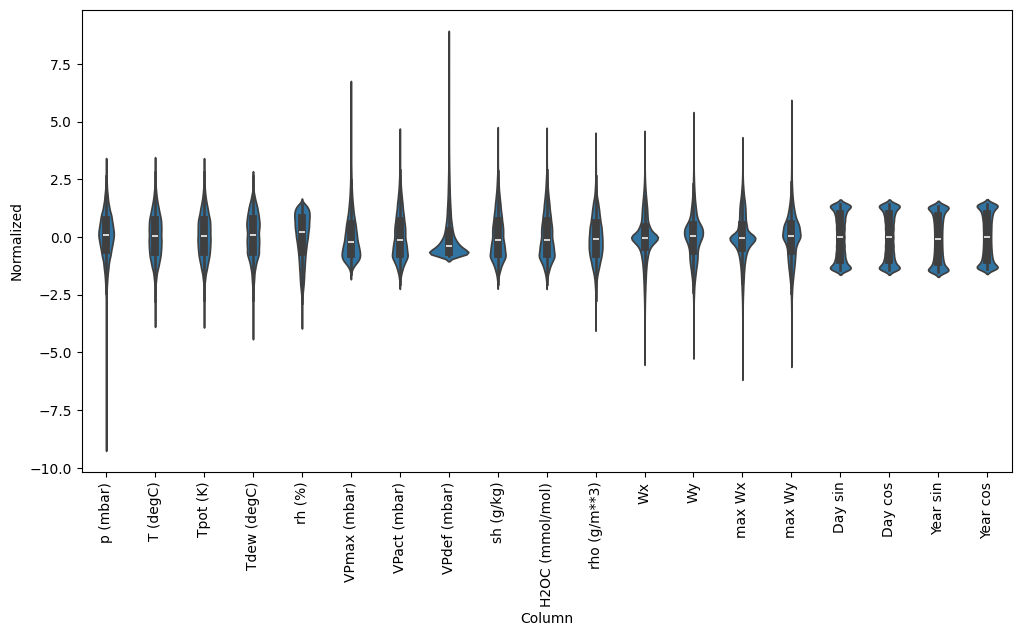

In [ ]:
df_std = (df - train_mean) / train_std
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df.keys(), rotation=90)

data windowing here is implemented with hours and you can set the input of hours and how far you want to predict with what features

In [ ]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

making 2 windows with window size, input, labels, and label columns

In [ ]:
w1 = WindowGenerator(input_width=24, label_width=1, shift=24,
                     label_columns=['T (degC)'])
print(w1)

w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     label_columns=['T (degC)'])
print(w2)

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['T (degC)']
Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['T (degC)']


Split into two windows of one label to be predicted and the input information

In [ ]:
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

Test of split

In [ ]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 19)
Inputs shape: (3, 6, 19)
Labels shape: (3, 1, 1)


visualization of the split windows

In [ ]:
w2.example = example_inputs, example_labels

def plot(self, model=None, plot_col='T (degC)', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

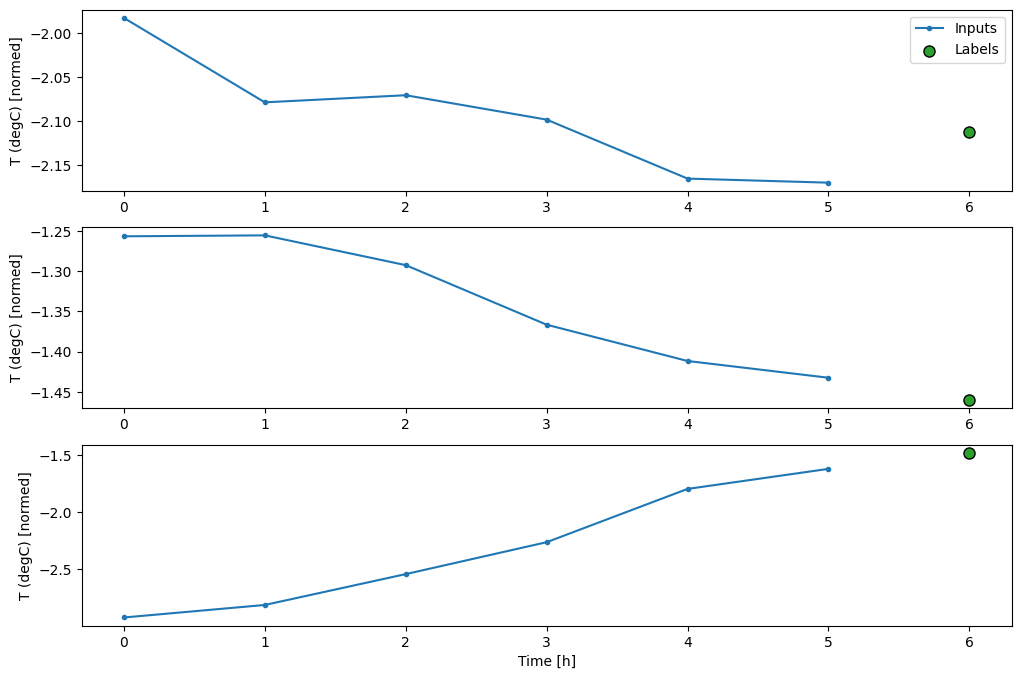

In [ ]:
w2.plot()

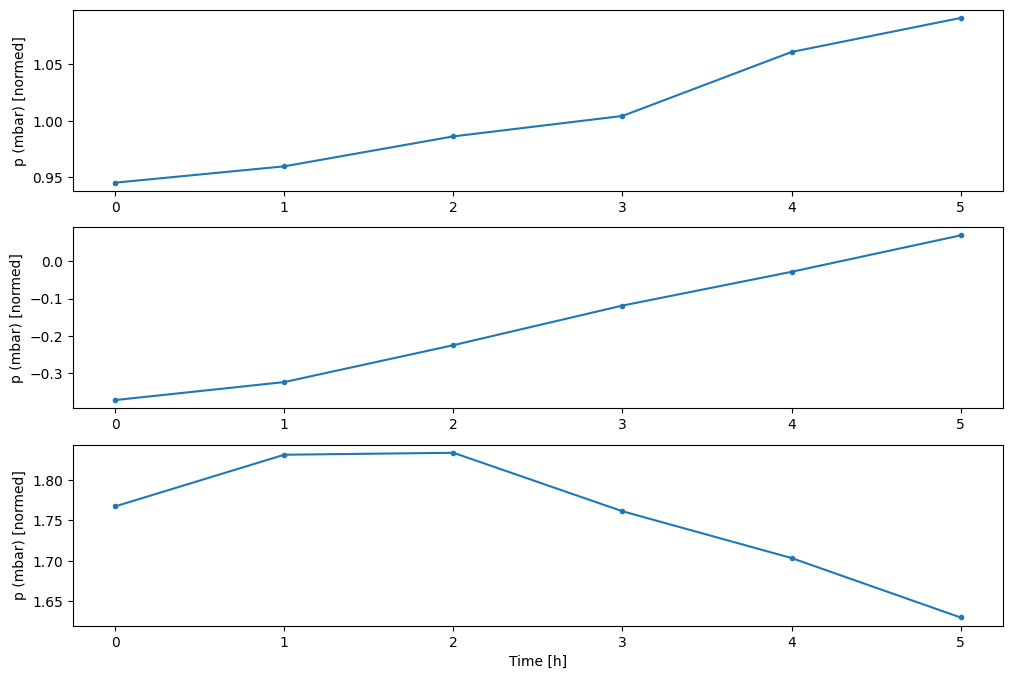

In [ ]:
w2.plot(plot_col='p (mbar)')

turning dataframe into tf dataset which is better for model ingestion and batching

In [ ]:
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

accessor funcs

In [ ]:
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

Show dataset specifications

In [ ]:
# Each element is an (inputs, label) pair.
w2.train.element_spec

(TensorSpec(shape=(None, 6, 19), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

show the batches created by the dataset

In [ ]:
for example_inputs, example_labels in w2.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 6, 19)
Labels shape (batch, time, features): (32, 1, 1)


Making a model that predicts one hour on a single feature

In [ ]:
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1,
    label_columns=['T (degC)'])
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['T (degC)']

iterate the model over the batches

In [ ]:
for example_inputs, example_labels in single_step_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 1, 19)
Labels shape (batch, time, features): (32, 1, 1)


Starting with predicting no chnage as a baseline performance of the single output model

In [ ]:
class Baseline(tf.keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

In [ ]:
baseline = Baseline(label_index=column_indices['T (degC)'])

baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                 metrics=[tf.keras.metrics.MeanAbsoluteError()])

val_performance = {}
performance = {}
val_performance['Baseline'] = baseline.evaluate(single_step_window.val, return_dict=True)
performance['Baseline'] = baseline.evaluate(single_step_window.test, verbose=0, return_dict=True)

439/439 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0128 - mean_absolute_error: 0.0785


Each batch through time is indepedent from each other. so no interaction from the previous to impact the current prediction being made

In [ ]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1,
    label_columns=['T (degC)'])

wide_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['T (degC)']

show the shape and the plot

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', baseline(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


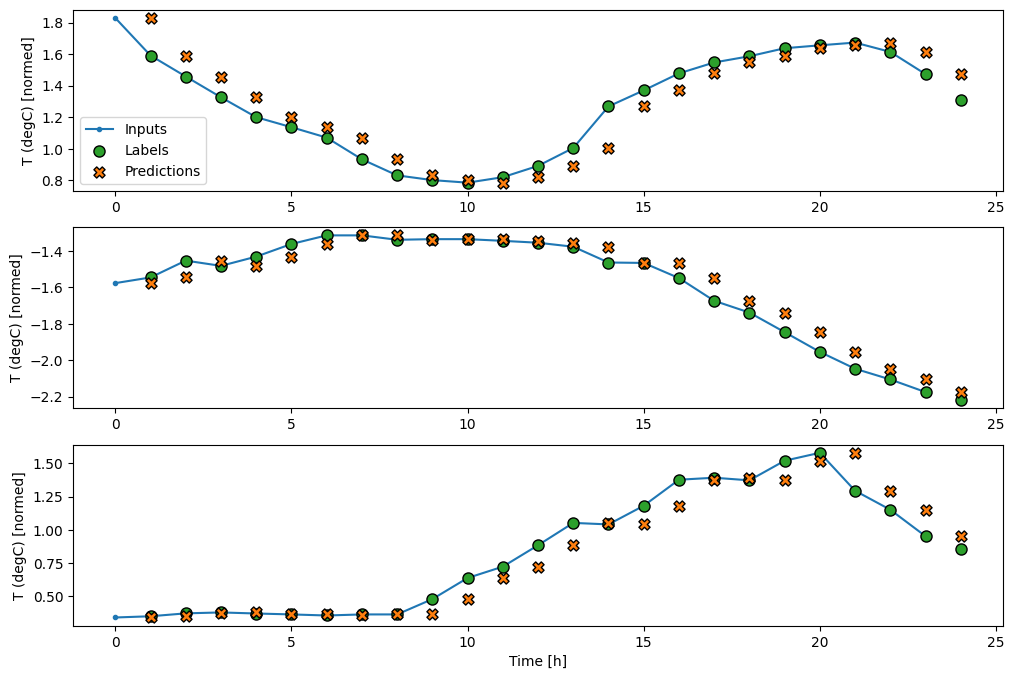

In [ ]:
wide_window.plot(baseline)

Making and training linear model with no transformation for activation making it just linear transformations

In [ ]:
linear = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1)
])

print('Input shape:', single_step_window.example[0].shape)
print('Output shape:', linear(single_step_window.example[0]).shape)

Input shape: (32, 1, 19)
Output shape: (32, 1, 1)


In [ ]:
MAX_EPOCHS = 20

def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

Eval

In [ ]:
history = compile_and_fit(linear, single_step_window)

val_performance['Linear'] = linear.evaluate(single_step_window.val, return_dict=True)
performance['Linear'] = linear.evaluate(single_step_window.test, verbose=0, return_dict=True)

Epoch 1/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.4581 - mean_absolute_error: 0.3895 - val_loss: 0.0199 - val_mean_absolute_error: 0.1043
Epoch 2/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0141 - mean_absolute_error: 0.0889 - val_loss: 0.0111 - val_mean_absolute_error: 0.0792
Epoch 3/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0106 - mean_absolute_error: 0.0763 - val_loss: 0.0099 - val_mean_absolute_error: 0.0742
Epoch 4/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.0099 - mean_absolute_error: 0.0733 - val_loss: 0.0094 - val_mean_absolute_error: 0.0726
Epoch 5/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0095 - mean_absolute_error: 0.0715 - val_loss: 0.0090 - val_mean_absolute_error: 0.0707
Epoch 6/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0093 - mean_absolute_error: 0.0707 - val_loss: 0.0090 - val_mean_absolute_error: 0.0709
Epoch 7/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 0.0092 - mean_absolu

wide window visualizations

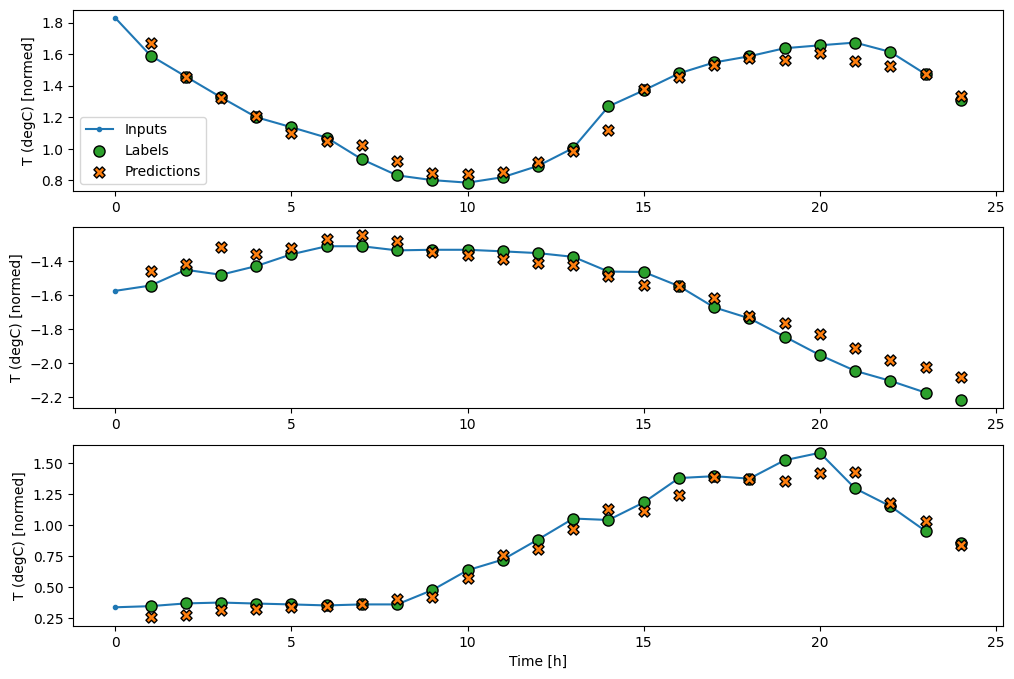

In [ ]:
wide_window.plot(linear)

showing the weights of each layers weight
Random initialization could run the risk of not having a weight on certain features

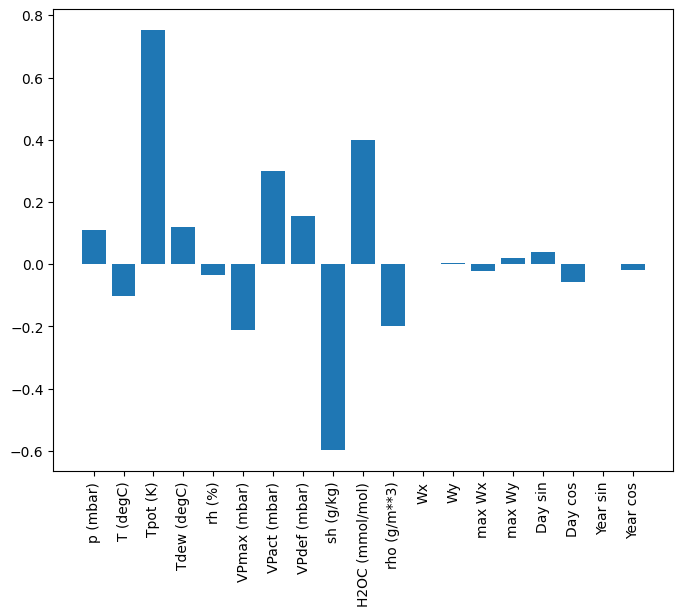

In [ ]:
plt.bar(x = range(len(train_df.columns)),
        height=linear.layers[0].kernel[:,0].numpy())
axis = plt.gca()
axis.set_xticks(range(len(train_df.columns)))
_ = axis.set_xticklabels(train_df.columns, rotation=90)

Multi-layer version

In [ ]:
dense = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=1)
])

history = compile_and_fit(dense, single_step_window)

val_performance['Dense'] = dense.evaluate(single_step_window.val, return_dict=True)
performance['Dense'] = dense.evaluate(single_step_window.test, verbose=0, return_dict=True)

Epoch 1/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0150 - mean_absolute_error: 0.0806 - val_loss: 0.0074 - val_mean_absolute_error: 0.0624
Epoch 2/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0079 - mean_absolute_error: 0.0644 - val_loss: 0.0078 - val_mean_absolute_error: 0.0639
Epoch 3/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 0.0075 - mean_absolute_error: 0.0627 - val_loss: 0.0071 - val_mean_absolute_error: 0.0612
Epoch 4/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0072 - mean_absolute_error: 0.0608 - val_loss: 0.0072 - val_mean_absolute_error: 0.0606
Epoch 5/20
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0071 - mean_absolute_error: 0.0601 - val_loss: 0.0079 - val_mean_absolute_error: 0.0623
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0079 - mean_absolute_error: 0.0623


Creating new window and plotting it

In [ ]:
CONV_WIDTH = 3
conv_window = WindowGenerator(
    input_width=CONV_WIDTH,
    label_width=1,
    shift=1,
    label_columns=['T (degC)'])

conv_window

Total window size: 4
Input indices: [0 1 2]
Label indices: [3]
Label column name(s): ['T (degC)']

Text(0.5, 0.98, 'Given 3 hours of inputs, predict 1 hour into the future.')

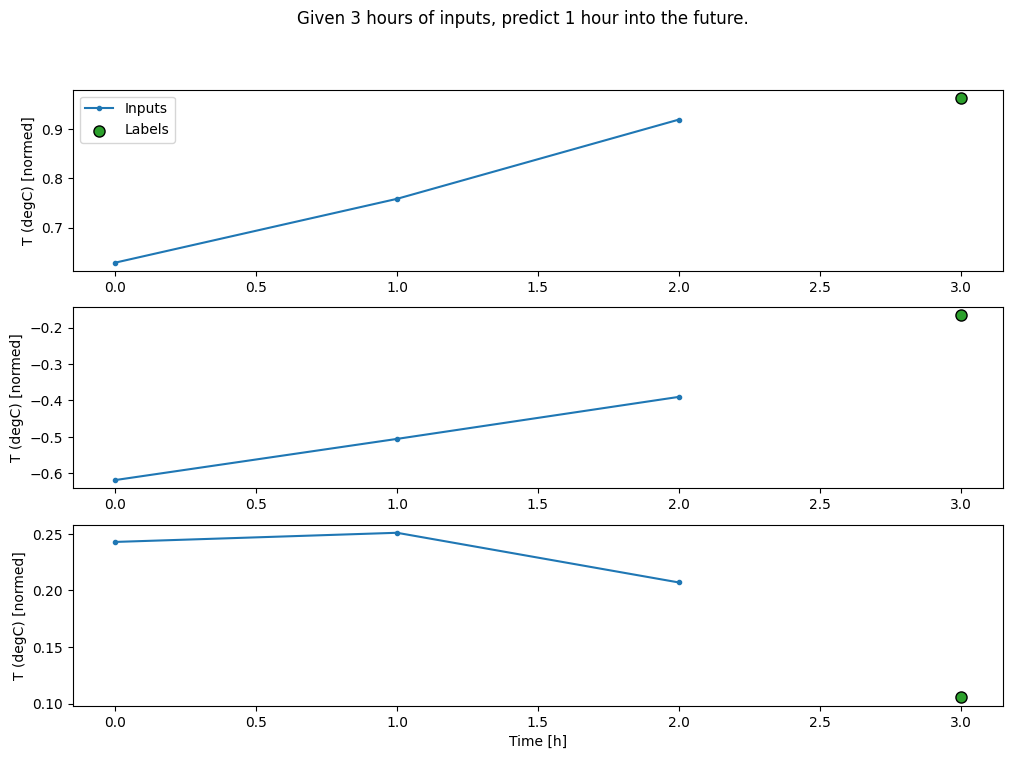

In [ ]:
conv_window.plot()
plt.suptitle("Given 3 hours of inputs, predict 1 hour into the future.")

Train, fit, and plot model

In [ ]:
multi_step_dense = tf.keras.Sequential([
    # Shape: (time, features) => (time*features)
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
    # Add back the time dimension.
    # Shape: (outputs) => (1, outputs)
    tf.keras.layers.Reshape([1, -1]),
])

In [ ]:
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', multi_step_dense(conv_window.example[0]).shape)

Input shape: (32, 3, 19)
Output shape: (32, 1, 1)


In [ ]:
history = compile_and_fit(multi_step_dense, conv_window)

IPython.display.clear_output()
val_performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.val, return_dict=True)
performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.test, verbose=0, return_dict=True)

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0062 - mean_absolute_error: 0.0554


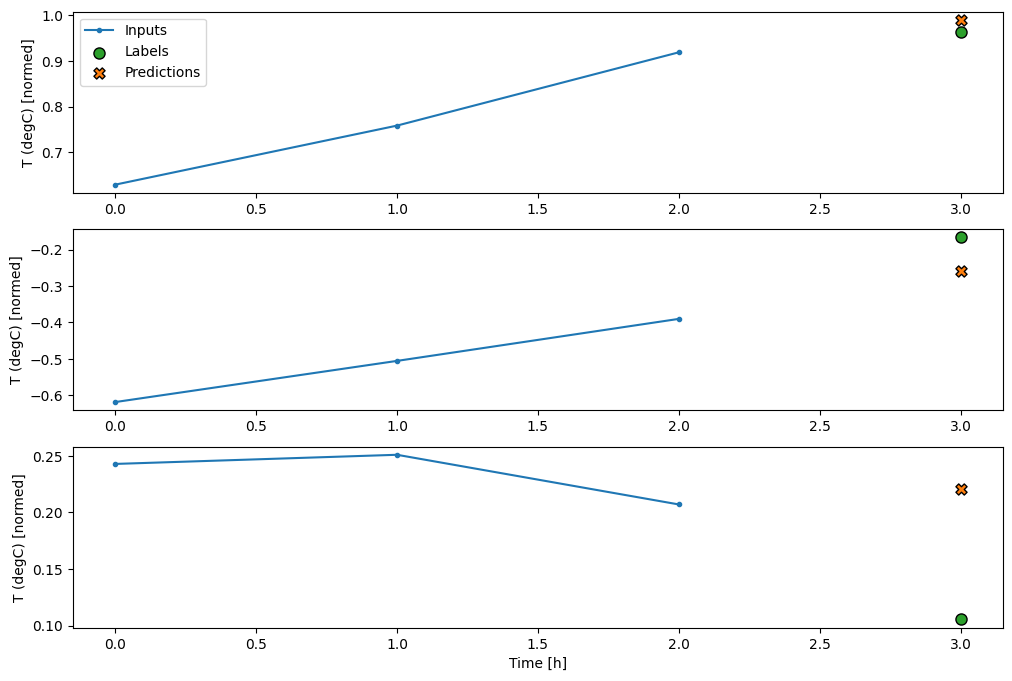

In [ ]:
conv_window.plot(multi_step_dense)

Set up CNN and show outputs to compare with multilayer

In [ ]:
conv_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32,
                           kernel_size=(CONV_WIDTH,),
                           activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1),
])

In [ ]:
print("Conv model on `conv_window`")
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', conv_model(conv_window.example[0]).shape)

Conv model on `conv_window`
Input shape: (32, 3, 19)
Output shape: (32, 1, 1)


In [ ]:
history = compile_and_fit(conv_model, conv_window)

IPython.display.clear_output()
val_performance['Conv'] = conv_model.evaluate(conv_window.val, return_dict=True)
performance['Conv'] = conv_model.evaluate(conv_window.test, verbose=0, return_dict=True)

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0072 - mean_absolute_error: 0.0613


Showing how CNN can use different shapes

In [ ]:
print("Wide window")
print('Input shape:', wide_window.example[0].shape)
print('Labels shape:', wide_window.example[1].shape)
print('Output shape:', conv_model(wide_window.example[0]).shape)

Wide window
Input shape: (32, 24, 19)
Labels shape: (32, 24, 1)
Output shape: (32, 22, 1)


There is now a need to balance the output and input. This would need to be fixed for training or plotting

In [ ]:
LABEL_WIDTH = 24
INPUT_WIDTH = LABEL_WIDTH + (CONV_WIDTH - 1)
wide_conv_window = WindowGenerator(
    input_width=INPUT_WIDTH,
    label_width=LABEL_WIDTH,
    shift=1,
    label_columns=['T (degC)'])

wide_conv_window

Total window size: 27
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Label indices: [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26]
Label column name(s): ['T (degC)']

Show changes

In [ ]:
print("Wide conv window")
print('Input shape:', wide_conv_window.example[0].shape)
print('Labels shape:', wide_conv_window.example[1].shape)
print('Output shape:', conv_model(wide_conv_window.example[0]).shape)

Wide conv window
Input shape: (32, 26, 19)
Labels shape: (32, 24, 1)
Output shape: (32, 24, 1)


Plot this new model

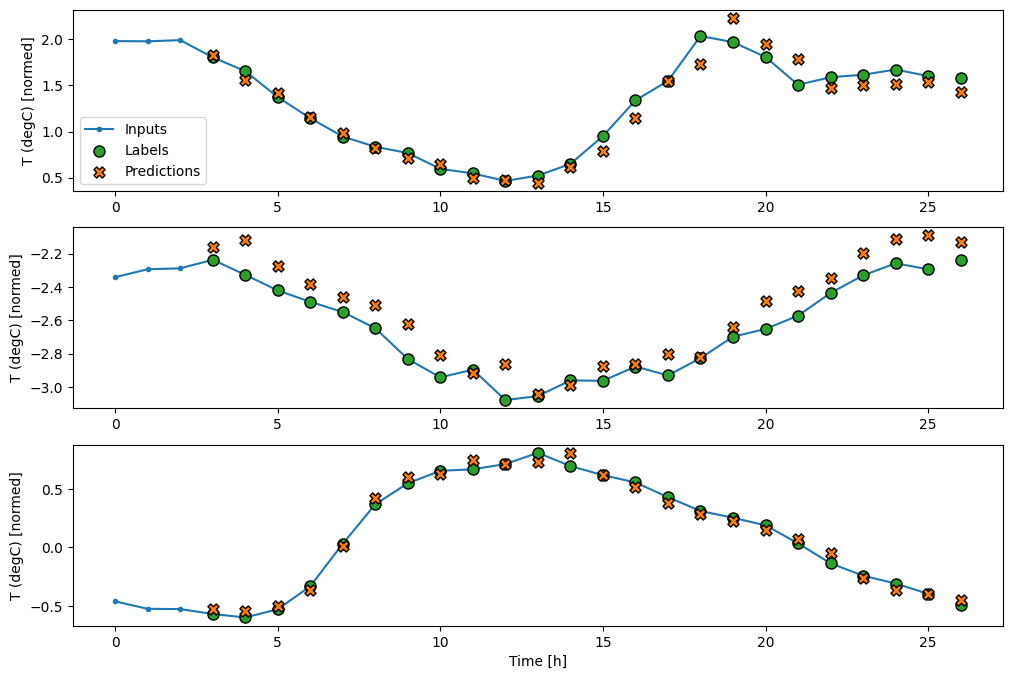

In [ ]:
wide_conv_window.plot(conv_model)

Now testing performance with an RNN model. It uses an internal state to move through a series of internal outputs to give one final output steo by step. You can also have a version with multiple steps being done and visible which is good for stacking RNN layers or training multiple steps at once.

Creating model

In [ ]:
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
])

RNN is good because of this sequential ability but not good for large scale/long sequences because of memory and the gradients decaying as backpropagation extends.

Shape

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


fitting and plotting

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0056 - mean_absolute_error: 0.0511


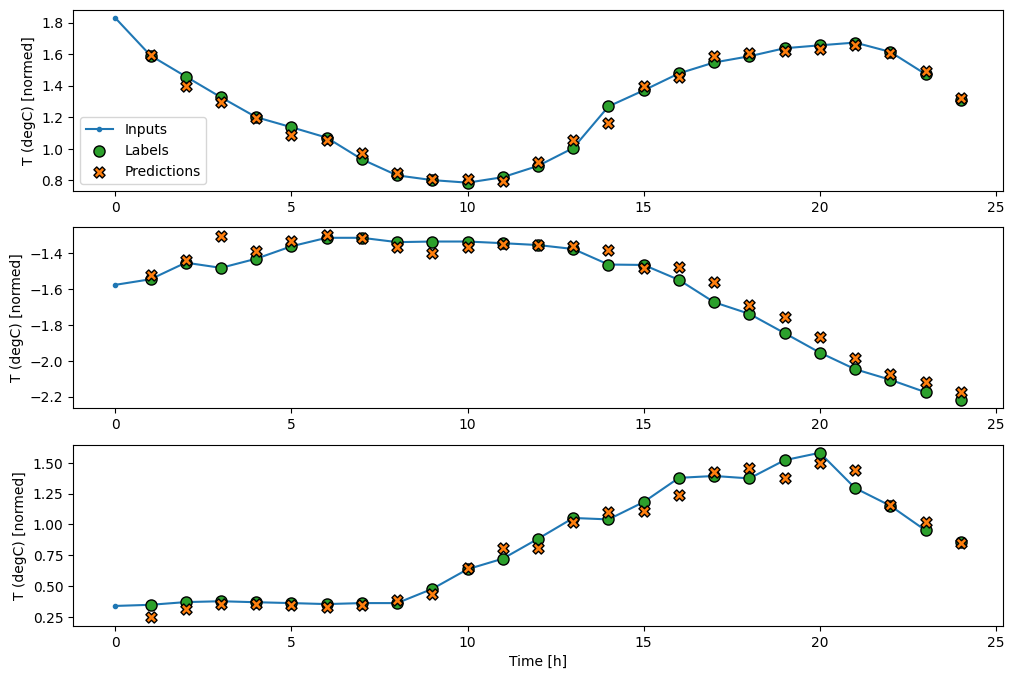

In [ ]:
history = compile_and_fit(lstm_model, wide_window)

IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val, return_dict=True)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

wide_window.plot(lstm_model)

Performance views

In [ ]:
cm = lstm_model.metrics[1]
cm.metrics

[<MeanAbsoluteError name=mean_absolute_error>]

In [ ]:
val_performance

{'Baseline': {'loss': 0.012845643796026707,
  'mean_absolute_error': 0.07846631854772568},
 'Linear': {'loss': 0.008894667960703373,
  'mean_absolute_error': 0.07044278085231781},
 'Dense': {'loss': 0.007902628742158413,
  'mean_absolute_error': 0.06234130635857582},
 'Multi step dense': {'loss': 0.0062117064371705055,
  'mean_absolute_error': 0.05538357049226761},
 'Conv': {'loss': 0.007240732200443745,
  'mean_absolute_error': 0.06134585291147232},
 'LSTM': {'loss': 0.005599487107247114,
  'mean_absolute_error': 0.051117200404405594}}

Plotting performance of validation vs test

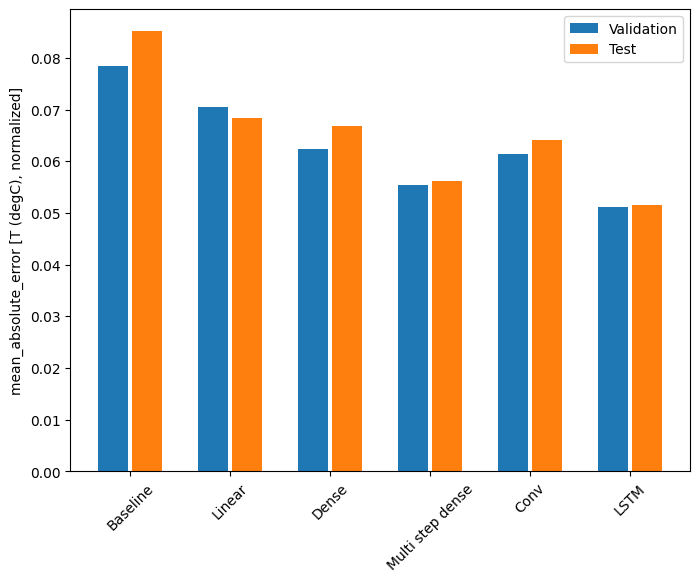

In [ ]:
x = np.arange(len(performance))
width = 0.3
metric_name = 'mean_absolute_error'
val_mae = [v[metric_name] for v in val_performance.values()]
test_mae = [v[metric_name] for v in performance.values()]

plt.ylabel('mean_absolute_error [T (degC), normalized]')
plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=performance.keys(),
           rotation=45)
_ = plt.legend()

General performance of all models

In [ ]:
for name, value in performance.items():
  print(f'{name:12s}: {value[metric_name]:0.4f}')

Baseline    : 0.0852
Linear      : 0.0685
Dense       : 0.0669
Multi step dense: 0.0562
Conv        : 0.0642
LSTM        : 0.0515


Now the tutorial moves on to multistep prediction models with a singleshot method

Setup window

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
Label column name(s): None

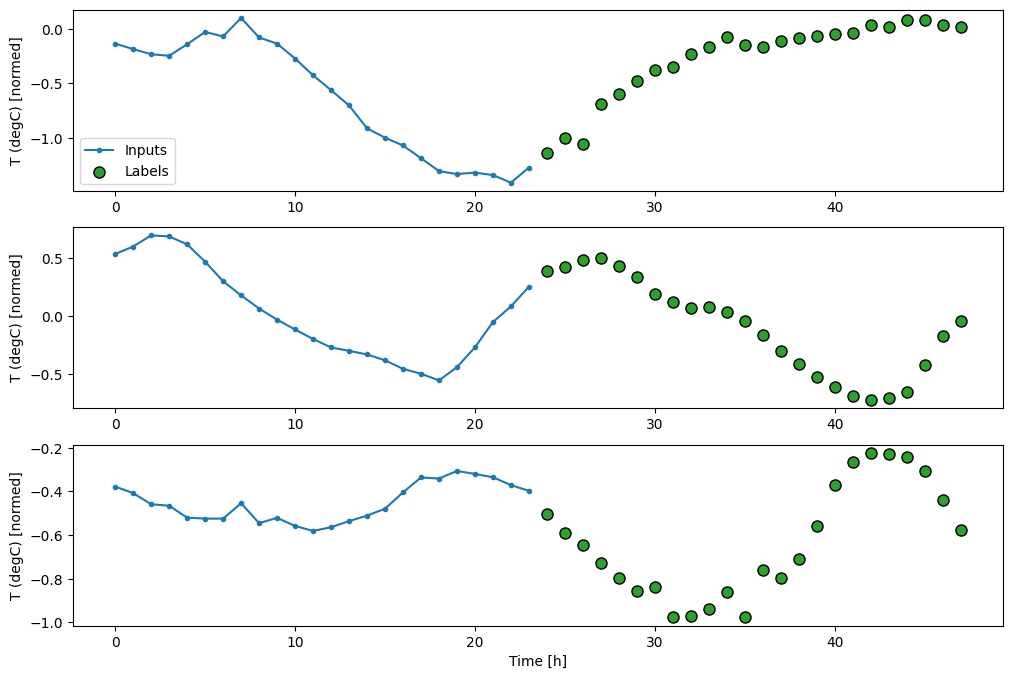

In [ ]:
OUT_STEPS = 24
multi_window = WindowGenerator(input_width=24,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS)

multi_window.plot()
multi_window

Slight change on baseline to have multiple predictions then plot

437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6285 - mean_absolute_error: 0.5007


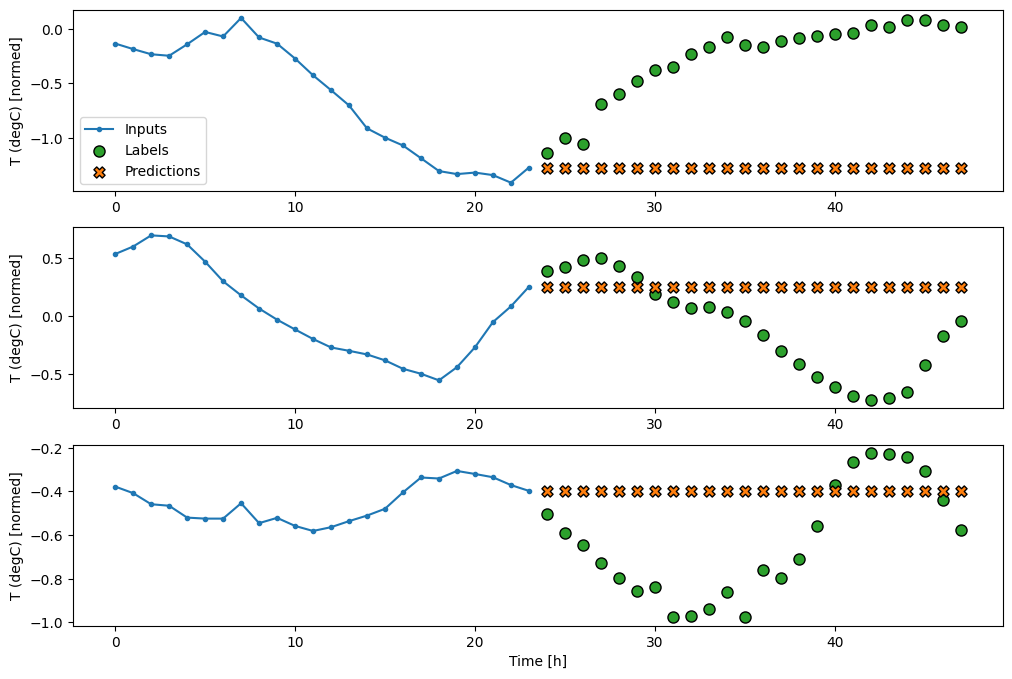

In [ ]:
class MultiStepLastBaseline(tf.keras.Model):
  def call(self, inputs):
    return tf.tile(inputs[:, -1:, :], [1, OUT_STEPS, 1])

last_baseline = MultiStepLastBaseline()
last_baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                      metrics=[tf.keras.metrics.MeanAbsoluteError()])

multi_val_performance = {}
multi_performance = {}

multi_val_performance['Last'] = last_baseline.evaluate(multi_window.val, return_dict=True)
multi_performance['Last'] = last_baseline.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(last_baseline)

Now with lack of change on days assumption

437/437 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.4270 - mean_absolute_error: 0.3959


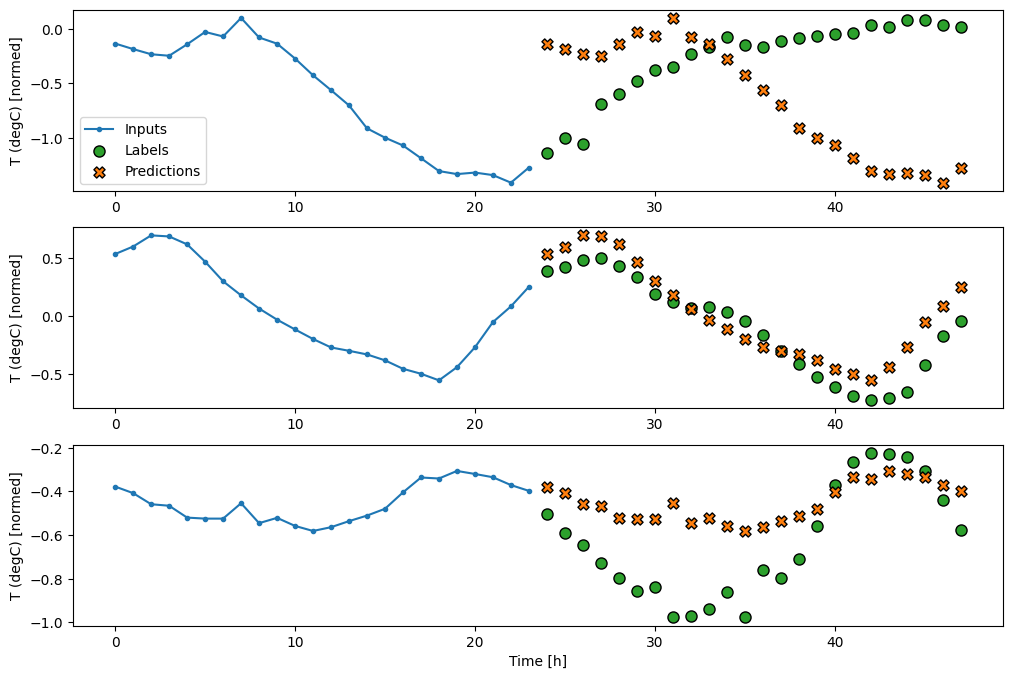

In [ ]:
class RepeatBaseline(tf.keras.Model):
  def call(self, inputs):
    return inputs

repeat_baseline = RepeatBaseline()
repeat_baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                        metrics=[tf.keras.metrics.MeanAbsoluteError()])

multi_val_performance['Repeat'] = repeat_baseline.evaluate(multi_window.val, return_dict=True)
multi_performance['Repeat'] = repeat_baseline.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(repeat_baseline)

A linear model will be tested but it is shown it can't get the full picture because it can't see nonlinear relationships/ Only at a low dimension due to it's simplicity

437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2559 - mean_absolute_error: 0.3046


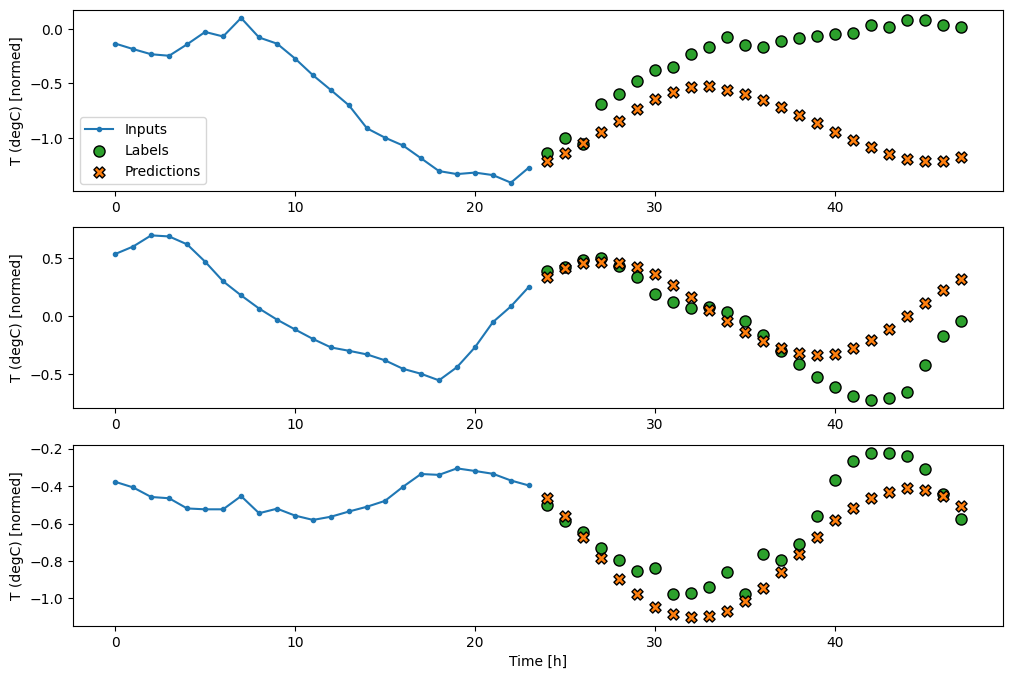

In [ ]:
multi_linear_model = tf.keras.Sequential([
    # Take the last time-step.
    # Shape [batch, time, features] => [batch, 1, features]
    tf.keras.layers.Lambda(lambda x: x[:, -1:, :]),
    # Shape => [batch, 1, out_steps*features]
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features]
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_linear_model, multi_window)

IPython.display.clear_output()
multi_val_performance['Linear'] = multi_linear_model.evaluate(multi_window.val, return_dict=True)
multi_performance['Linear'] = multi_linear_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_linear_model)

More layers can give it more power(understanding) but it is stil limited by a single input to then predict multiple

437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2213 - mean_absolute_error: 0.2818


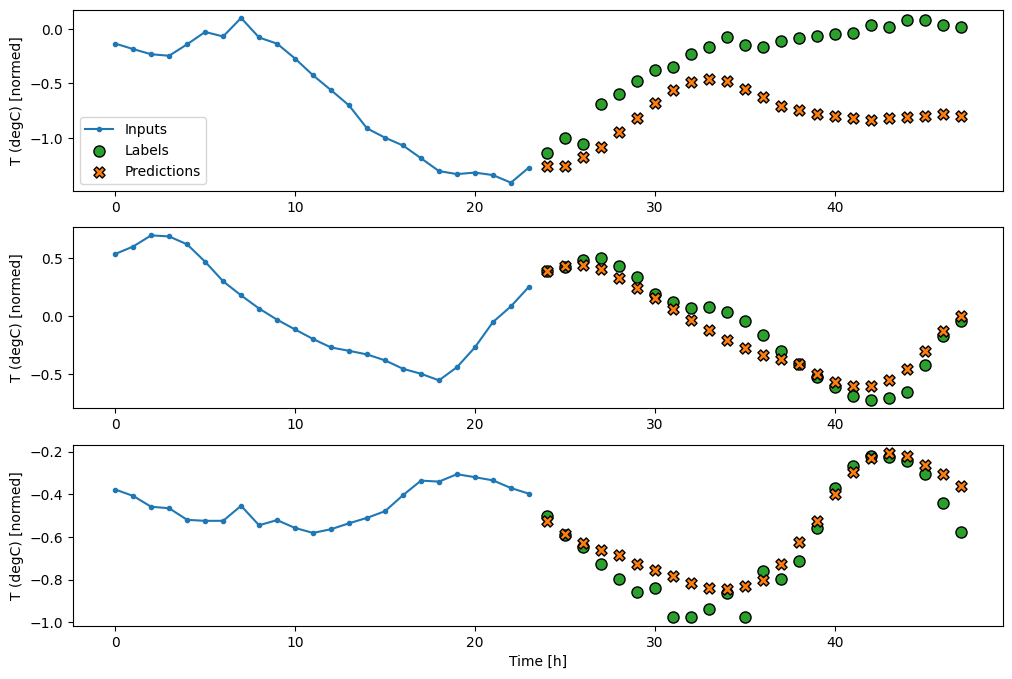

In [ ]:
multi_dense_model = tf.keras.Sequential([
    # Take the last time step.
    # Shape [batch, time, features] => [batch, 1, features]
    tf.keras.layers.Lambda(lambda x: x[:, -1:, :]),
    # Shape => [batch, 1, dense_units]
    tf.keras.layers.Dense(512, activation='relu'),
    # Shape => [batch, out_steps*features]
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features]
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_dense_model, multi_window)

IPython.display.clear_output()
multi_val_performance['Dense'] = multi_dense_model.evaluate(multi_window.val, return_dict=True)
multi_performance['Dense'] = multi_dense_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_dense_model)

CNN

Wide window gives more context to patterns and change

437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2197 - mean_absolute_error: 0.2860


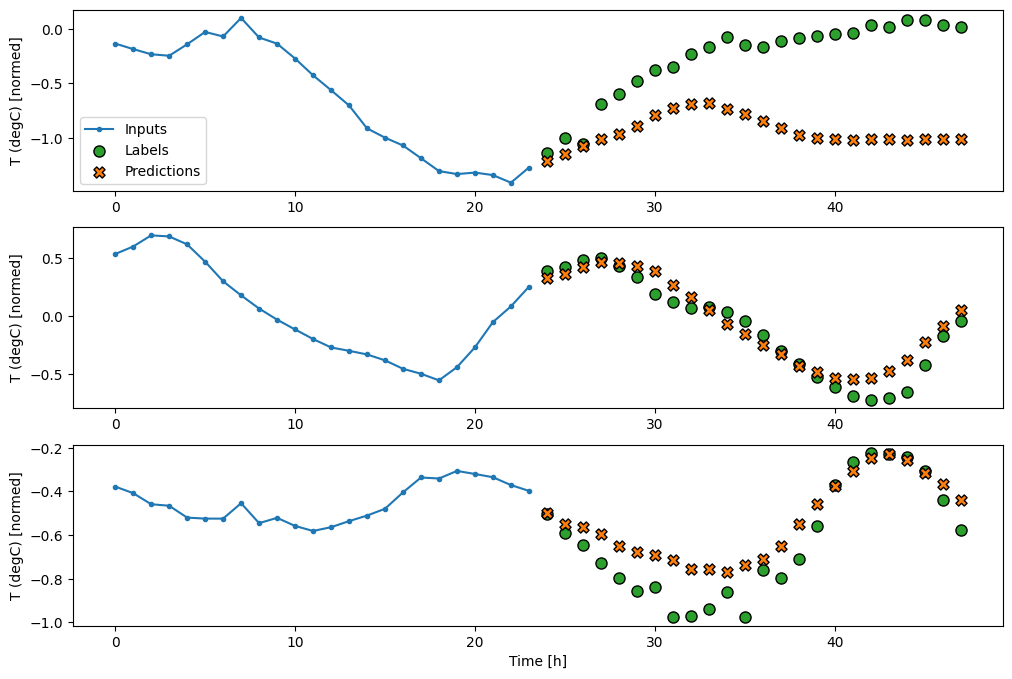

In [ ]:
CONV_WIDTH = 3
multi_conv_model = tf.keras.Sequential([
    # Shape [batch, time, features] => [batch, CONV_WIDTH, features]
    tf.keras.layers.Lambda(lambda x: x[:, -CONV_WIDTH:, :]),
    # Shape => [batch, 1, conv_units]
    tf.keras.layers.Conv1D(256, activation='relu', kernel_size=(CONV_WIDTH)),
    # Shape => [batch, 1,  out_steps*features]
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features]
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_conv_model, multi_window)

IPython.display.clear_output()

multi_val_performance['Conv'] = multi_conv_model.evaluate(multi_window.val, return_dict=True)
multi_performance['Conv'] = multi_conv_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_conv_model)

RNN

Can take a long history of inputs and find whats relevant before making the next 24 hours prediction

437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2138 - mean_absolute_error: 0.2841


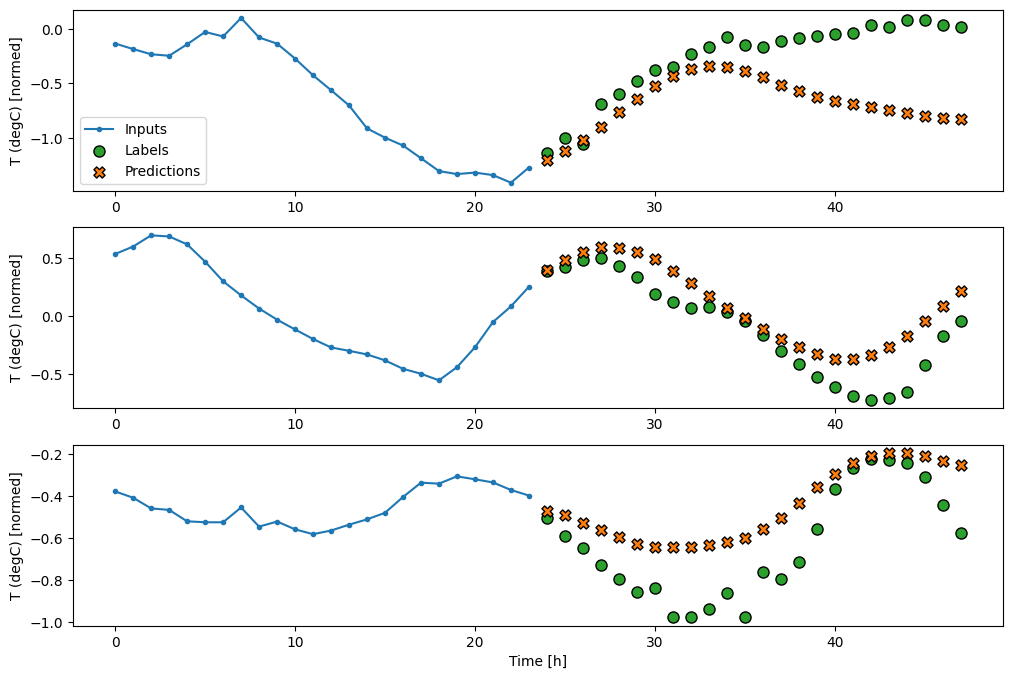

In [ ]:
multi_lstm_model = tf.keras.Sequential([
    # Shape [batch, time, features] => [batch, lstm_units].
    # Adding more `lstm_units` just overfits more quickly.
    tf.keras.layers.LSTM(32, return_sequences=False),
    # Shape => [batch, out_steps*features].
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features].
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_lstm_model, multi_window)

IPython.display.clear_output()

multi_val_performance['LSTM'] = multi_lstm_model.evaluate(multi_window.val, return_dict=True)
multi_performance['LSTM'] = multi_lstm_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_lstm_model)

Autoregressive model

This model makes predictions step by step but there is interaction from previous inputs that are ingested to get the next output. You can have a varying length of returned outputs and many of the single shot models can be turned to autoregressive

In the tutorial this will be done with a RNN model with manual managment

In [ ]:
class FeedBack(tf.keras.Model):
  def __init__(self, units, out_steps):
    super().__init__()
    self.out_steps = out_steps
    self.units = units
    self.lstm_cell = tf.keras.layers.LSTMCell(units)
    # Also wrap the LSTMCell in an RNN to simplify the `warmup` method.
    self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
    self.dense = tf.keras.layers.Dense(num_features)

In [ ]:
feedback_model = FeedBack(units=32, out_steps=OUT_STEPS)

Setting the warmup for the RNN's internal state through history

In [ ]:
def warmup(self, inputs):
  # inputs.shape => (batch, time, features)
  # x.shape => (batch, lstm_units)
  x, *state = self.lstm_rnn(inputs)

  # predictions.shape => (batch, features)
  prediction = self.dense(x)
  return prediction, state

FeedBack.warmup = warmup


Show internal state and make the first prediction

In [ ]:
prediction, state = feedback_model.warmup(multi_window.example[0])
print(prediction.shape)



(32, 19)


now iterating the model input feeding and storing outputs into a python list

In [ ]:
def call(self, inputs, training=None):
  # Use a TensorArray to capture dynamically unrolled outputs.
  predictions = []
  # Initialize the LSTM state.
  prediction, state = self.warmup(inputs)

  # Insert the first prediction.
  predictions.append(prediction)

  # Run the rest of the prediction steps.
  for n in range(1, self.out_steps):
    # Use the last prediction as input.
    x = prediction
    # Execute one lstm step.
    x, state = self.lstm_cell(x, states=state,
                              training=training)
    # Convert the lstm output to a prediction.
    prediction = self.dense(x)
    # Add the prediction to the output.
    predictions.append(prediction)

  # predictions.shape => (time, batch, features)
  predictions = tf.stack(predictions)
  # predictions.shape => (batch, time, features)
  predictions = tf.transpose(predictions, [1, 0, 2])
  return predictions

FeedBack.call = call

In [ ]:
print('Output shape (batch, time, features): ', feedback_model(multi_window.example[0]).shape)

Output shape (batch, time, features):  (32, 24, 19)


Train and plot

437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2311 - mean_absolute_error: 0.3047


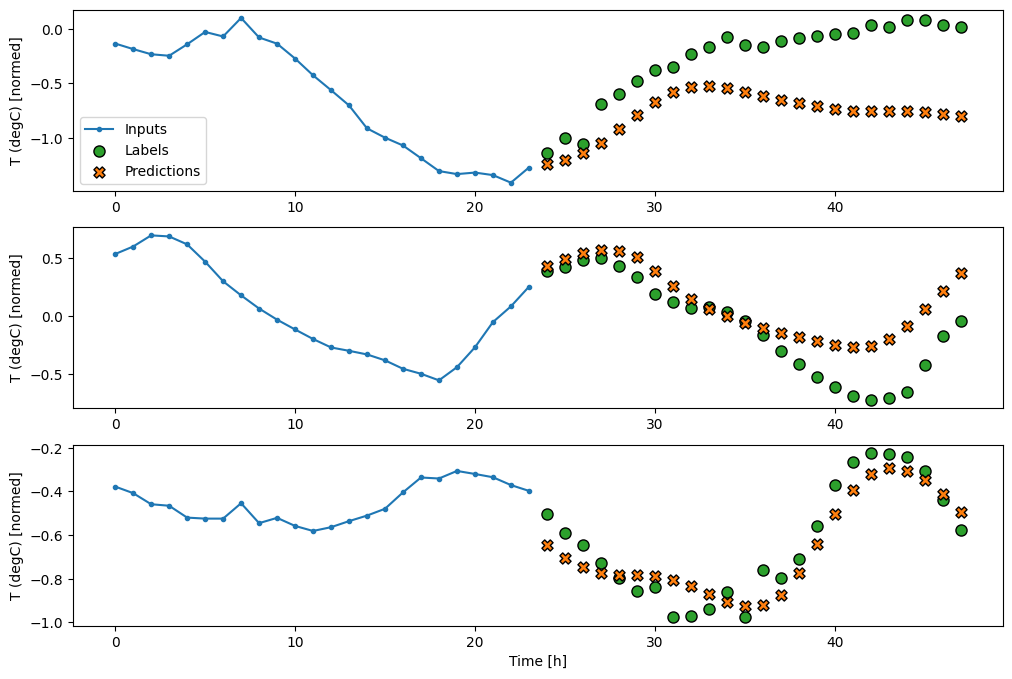

In [ ]:
history = compile_and_fit(feedback_model, multi_window)

IPython.display.clear_output()

multi_val_performance['AR LSTM'] = feedback_model.evaluate(multi_window.val, return_dict=True)
multi_performance['AR LSTM'] = feedback_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(feedback_model)

Show performance on each feature

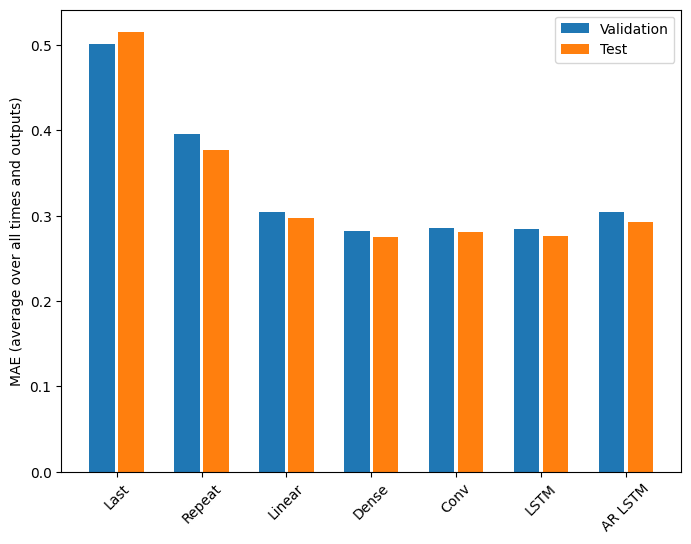

In [ ]:
x = np.arange(len(multi_performance))
width = 0.3

metric_name = 'mean_absolute_error'
val_mae = [v[metric_name] for v in multi_val_performance.values()]
test_mae = [v[metric_name] for v in multi_performance.values()]

plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=multi_performance.keys(),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

Average for each model through time steps

In [ ]:
for name, value in multi_performance.items():
  print(f'{name:8s}: {value[metric_name]:0.4f}')

Last    : 0.5157
Repeat  : 0.3774
Linear  : 0.2972
Dense   : 0.2753
Conv    : 0.2809
LSTM    : 0.2756
AR LSTM : 0.2920
